# Ridge Regression ( L2 Regularization)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

data = load_diabetes()

In [21]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [22]:
X = data.data
y = data.target

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=45)

### Apply Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression
L = LinearRegression()

In [25]:
L.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = L.predict(X_test)

In [27]:
from sklearn.metrics import r2_score,mean_squared_error
print("R2 score : ", r2_score(y_test,y_pred))
print("RMSE : ", np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score :  0.5188113124539249
RMSE :  48.72713760953253


### Apply Ridge Regression

In [28]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.0001)

In [29]:
R.fit(X_train,y_train)

,alpha,0.0001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [30]:
y_pred1=R.predict(X_test)

In [31]:
print("R2 score : ", r2_score(y_test,y_pred1))
print("RMSE : ", np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score :  0.5189732635884949
RMSE :  48.71893700181956


#### How Overfitting and Underfitting in happen in Ridge Regression?

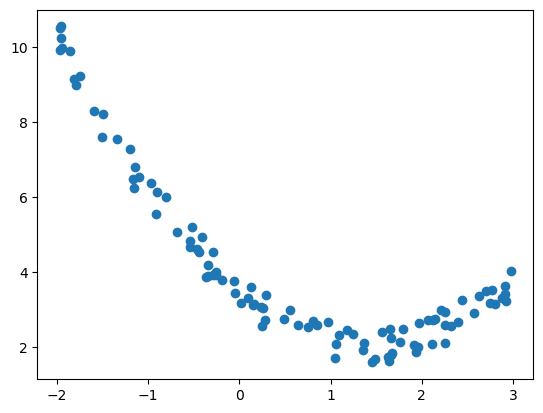

In [32]:
#Generate a Non-Linear Dataset

m = 100  #creating 100 samples.
#random.rand(m,1) → random values in [0, 1), Multiply by 5 → range becomes [0, 5), Subtract 2 → final range [-2, 3)
x1 = 5 * np.random.rand(m,1) - 2 
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.rand(m,1)
plt.scatter(x1,x2)
plt.show()

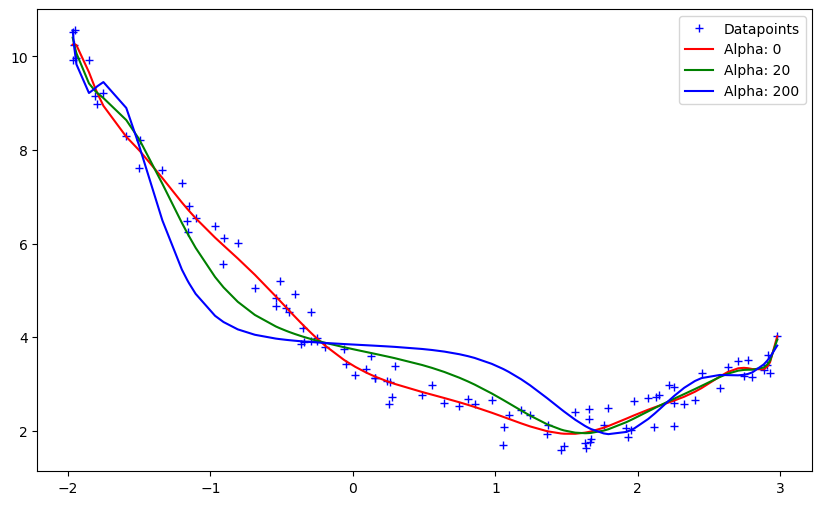

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1,x2,alpha):
    model = Pipeline([
        ('poly_feats',PolynomialFeatures(degree=16)), # x → [1, x, x², x³, ..., x¹⁶] 
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)
    
alphas = [0, 20, 200] # 0-Overfiting(Linear Regression), 20-Optimum result, 200-underfiting(very less slopes weight)
cs = ['r', 'g', 'b'] # color

plt.figure(figsize=(10,6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    #plot
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()